In [103]:
import torch

from src import model as models

## importamos los dataloaders
from src.datadogs import dog_train_loader, dog_test_loader

from src.utils import probar_modelo, comparar_modelos, calculo_perdida

from src.train import train_ae, train_metanca


In [2]:
# Configuración de hardware acelerado
device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f"Usando el dispositivo: {device}")

## para que los cambios en los files se apliquen sin reiniciar kernels
%load_ext autoreload
%autoreload 2

Usando el dispositivo: cuda


In [ ]:
## parametros para probar entrenamiento autoencoder

params_encoder_old = {
    'in_c': 3,
    # --- ENCODER ---
    'Conv2DParams1': {'out_c': 64, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1},
    'Conv2DParams2': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1},
    
    # Pass-through debe terminar con 128 canales y stride total de 2 para sumar con Conv2DParams2
    'PassThroughParams1': {'out_c': 64, 'kernel_size': 1, 'strides': 1, 'padding': 0, 
                           'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    'PassThroughParams2': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                           'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    'Conv2DParams3': {'out_c': 256, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.2},

    # --- DECODER ---
    'Conv2DTransposeParams3': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                               'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    'Conv2DTransposeParams2': {'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                               'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    # MixParams recibe d2_out (64) + c1_out (64), mantiene 64 canales
    'MixParams': {'out_c': 64, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                  'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    # Salida final: 3 canales para las 3 clases del dataset
    'Conv2DTransposeParams1': {'out_c': 3, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                               'activation': None, 'batch_normalization': False, 'dropout_rate': 0.0}
}

In [ ]:
params_encoder2 = {
    'in_c': 3,
    
    # Encoder
    # Conv1 define el canal de nuestro skip_out de alta resolución. 
    # Bajamos a 32 canales para balancear la carga computacional.
    'Conv2DParams1': {
        'out_c': 32, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1
    },
    
    # Conv2 comprime el espacio (/2) y sube canales. Terminamos con 64 canales.
    'Conv2DParams2': {
        'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1
    },
    
    # Camino Pass-through: Debe igualar exactamente la salida de Conv2DParams2 (64 canales y stride total de 2)
    'PassThroughParams1': {
        'out_c': 32, 'kernel_size': 1, 'strides': 1, 'padding': 0, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    'PassThroughParams2': {
        'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    
    # Capa final del Encoder (Conv3): Aquí colapsamos la información al espacio latente objetivo.
    'Conv2DParams3': {
        'out_c': 16, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1
    },

    # Decoder
    # TransConv3 procesa el latente del NCA (16 canales) y recupera la resolución espacial (*2).
    # Lo subimos a 64 canales para ir preparando el terreno de la mezcla.
    'Conv2DTransposeParams3': {
        'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    
    # TransConv2 recupera la resolución original (*2). 
    # CRÍTICO: Debe salir con 32 canales para coincidir con los 32 canales de 'Conv2DParams1' (skip_out).
    'Conv2DTransposeParams2': {
        'out_c': 32, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    
    # MixParams recibe la suma directa de d2_out (32) + c1_out (32).
    # Procesa la combinación manteniendo 32 canales para refinar bordes antes de clasificar.
    'MixParams': {
        'out_c': 32, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    
    # Salida final del Decoder: Proyecta los 32 canales a los 3 canales del trimapa (fondo, interior, borde)
    'Conv2DTransposeParams1': {
        'out_c': 3, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
        'activation': None, 'batch_normalization': False, 'dropout_rate': 0.0
    }
}

##con estos parametros el espacio se colapsa a 1/4 de la resolución original, con 16 canales en el latente para los nca

In [4]:
ae_model = models.AutoEncoderDown3(params_encoder2).to(device)

In [ ]:
ae_model.load_state_dict(torch.load("ae_model_og_2.pth", map_location=device))

<All keys matched successfully>

Loss en el batch de prueba (dice): 0.4656


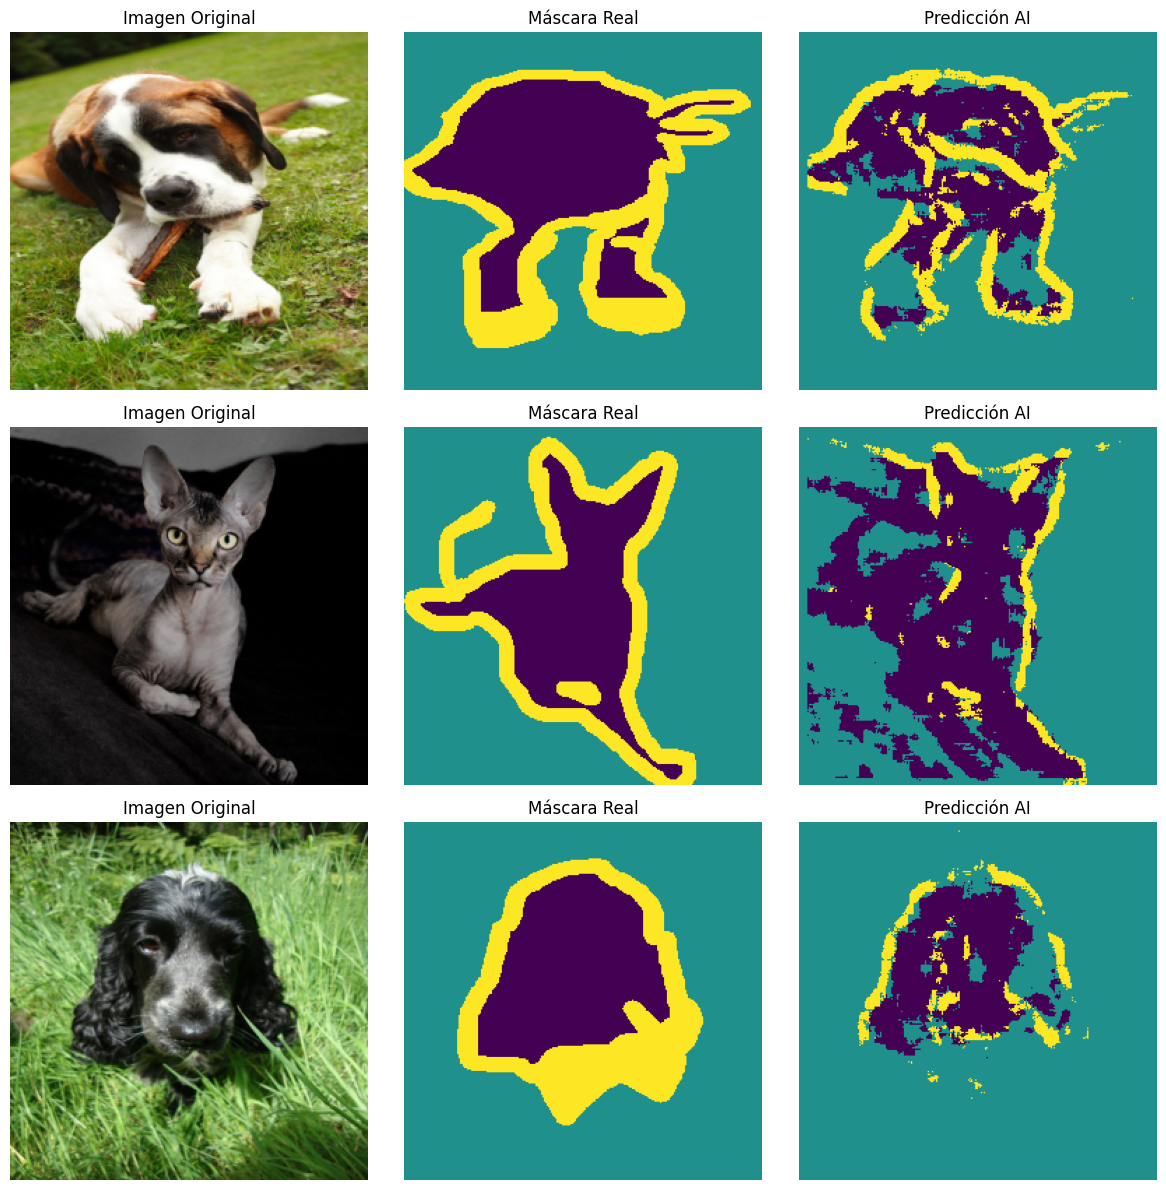

In [87]:
probar_modelo(ae_model, dog_test_loader, device)

In [91]:
meta_nca = models.MetaNCASegmenter(ae_params=params_encoder2, nca_steps=16).to(device)


In [ ]:
meta_nca.load_state_dict(torch.load("meta_nca_model_og_2.pth", map_location=device))

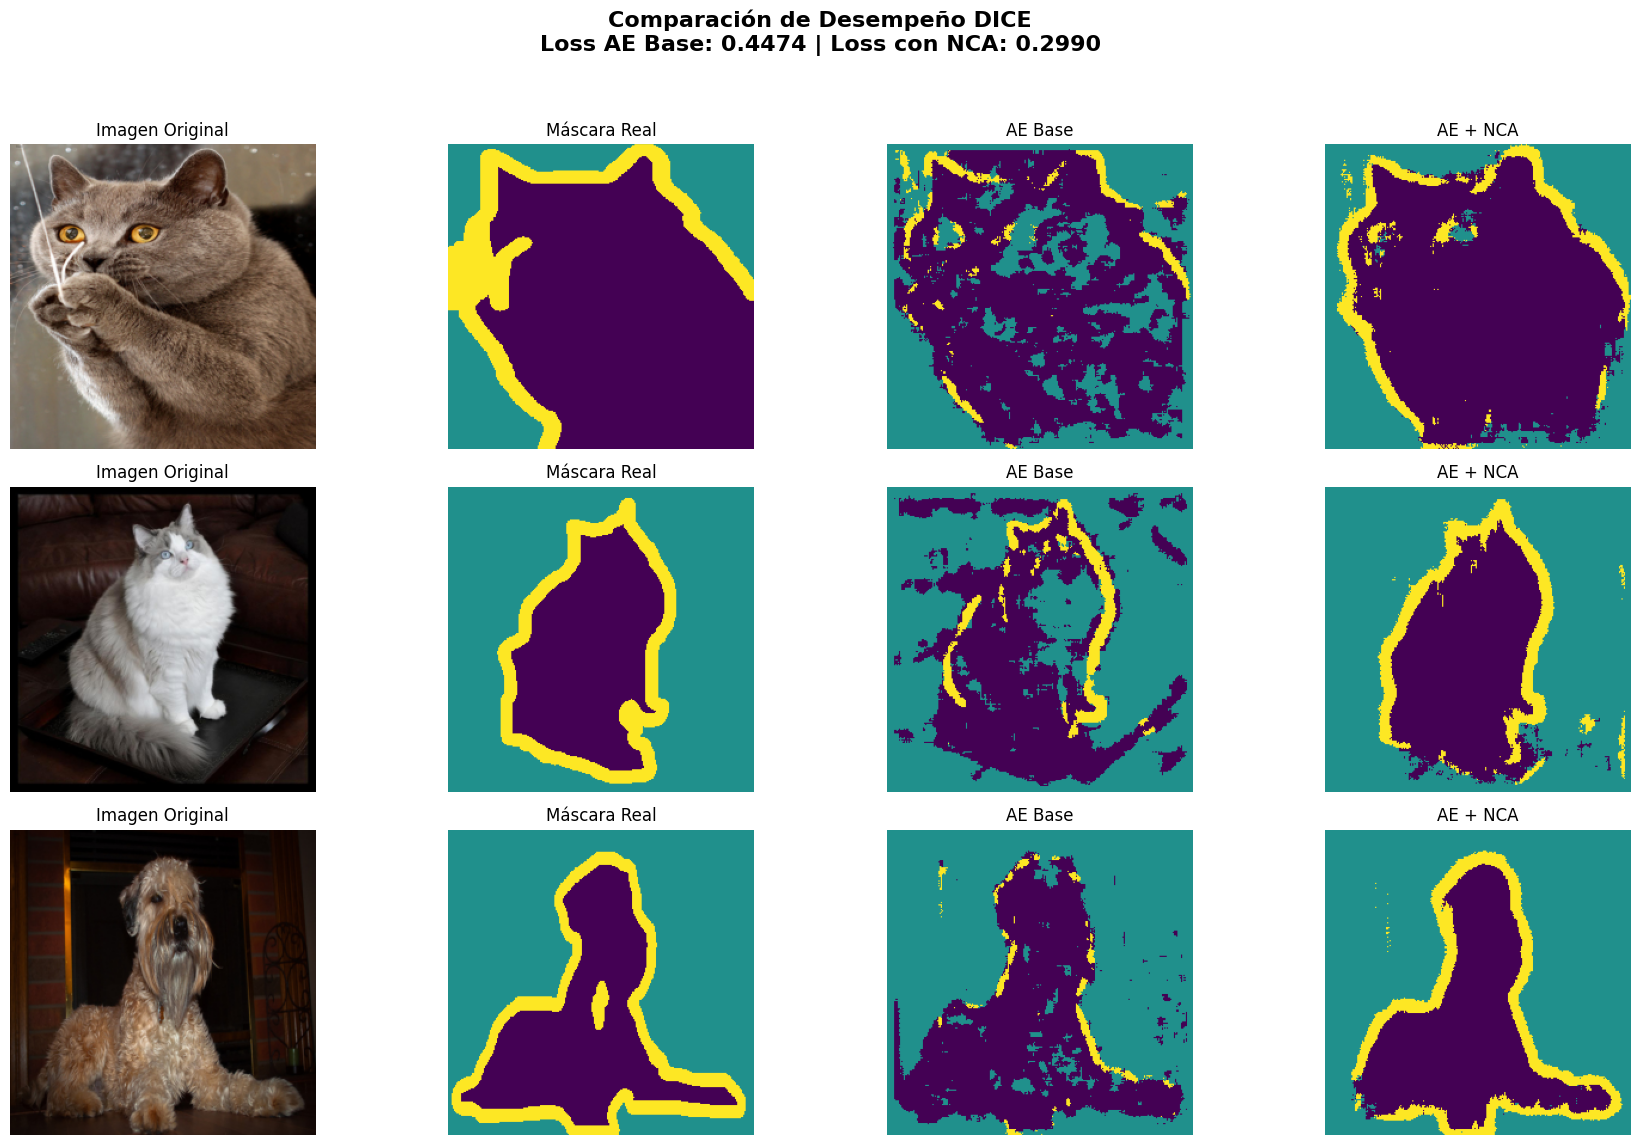

In [130]:
meta_nca.nca_steps = 64
comparar_modelos(ae_model, meta_nca, dog_test_loader, device)

### Coeficiente de Dice Multiclase Utilizado

Para evaluar el solapamiento global en todas las categorías de forma simultánea, se calcula el promedio simple sobre el conjunto de clases $C$:

$$\text{Dice Score} = \frac{1}{|C|} \sum_{c \in C} \frac{2 \sum_{i} p_{ic} g_{ic} + \epsilon}{\sum_{i} p_{ic}^2 + \sum_{i} g_{ic}^2 + \epsilon}$$

Donde la función de pérdida (**Dice Loss**) que el optimizador minimiza es el complemento a uno del puntaje:

$$\text{Dice Loss} = 1 - \text{Dice Score}$$

**Donde:**
* $|C|$: Número total de clases del trimapa ($|C| = 3$: Fondo, Contorno e Interior).
* $i$: Índice del píxel dentro de la grilla espacial $H \times W$.
* $p_{ic}$: Probabilidad predicha por el Decoder (vía Softmax) para el píxel $i$ en la clase $c$.
* $g_{ic}$: Valor binario real (*Ground Truth*) en formato One-Hot para el píxel $i$ en la clase $c$.
* $\epsilon$: Factor de suavizado numérico ($10^{-6}$) para prevenir divisiones por cero e indeterminaciones $\frac{0}{0}$.

In [114]:
# perdidas com metricas, 32 steps del NCA, en el test set
meta_nca.nca_steps = 32

dice = calculo_perdida(meta_nca, dog_test_loader, device, perdida="dice")

cross_entropy = calculo_perdida(meta_nca, dog_test_loader, device, perdida="cross_entropy")

print(f"Dice Loss Meta-NCA, 32 steps: {dice:.4f}")
print(f"Cross-Entropy Loss Meta-NCA, 32 steps: {cross_entropy:.4f}")

Dice Loss Meta-NCA, 32 steps: 0.3653
Cross-Entropy Loss Meta-NCA, 32 steps: 0.5028


In [113]:
# perdidas com metricas, 64 steps del NCA, en el test set

meta_nca.nca_steps = 64

dice_64 = calculo_perdida(meta_nca, dog_test_loader, device, perdida="dice")

cross_entropy_64 = calculo_perdida(meta_nca, dog_test_loader, device, perdida="cross_entropy")

print(f"Dice Loss Meta-NCA, 64 steps: {dice_64:.4f}")
print(f"Cross-Entropy Loss Meta-NCA, 64 steps: {cross_entropy_64:.4f}")

Dice Loss Meta-NCA, 64 steps: 0.3443
Cross-Entropy Loss Meta-NCA, 64 steps: 0.4763


In [109]:
dice_ae = calculo_perdida(ae_model, dog_test_loader, device, perdida="dice")

cross_entropy_ae = calculo_perdida(ae_model, dog_test_loader, device, perdida="cross_entropy")

print(f"Dice Loss ae solo: {dice_ae:.4f}")
print(f"Cross-Entropy Loss ae solo: {cross_entropy_ae:.4f}")

Dice Loss ae solo: 0.4610
Cross-Entropy Loss ae solo: 0.6389
